# ECG and PCG signal exploration across measured LVEF

This notebook supports visual, hypothesis-generating review of the four acquisition sites. It organizes patients by **measured LVEF**; it does not use model predictions. In this project, HFrEF is defined as LVEF $\leq 40\%$.

The labels *lowest LVEF*, *highest LVEF*, and *non-HFrEF* describe only this dataset variable. They do not establish overall health, diagnosis severity, or which features the model uses.

## Setup and configuration

The settings below control group size, random sampling, gallery pages, and the default signal window. The notebook works when launched from the project root or from `notebooks/`. Signals are loaded only when validation or a plot requests them.

In [16]:
from functools import lru_cache
from pathlib import Path
import sys
import warnings

import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.signal as scipy_signal
import seaborn as sns
import soundfile as sf
import torch
from IPython.display import clear_output, display

PROJECT_DIR = Path.cwd().resolve()
if not (PROJECT_DIR / 'src').is_dir() and (PROJECT_DIR.parent / 'src').is_dir():
    PROJECT_DIR = PROJECT_DIR.parent
if not (PROJECT_DIR / 'src').is_dir():
    raise FileNotFoundError('Run this notebook from the CardioFusion root or notebooks directory.')
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

warnings.filterwarnings('ignore', message='IProgress not found.*')
from src.preprocessing import (
    CHANNEL_ORDER, CHANNEL_ORDER_STRING, DURATION_SECONDS,
    ECG_FS, ECG_SAMPLES, PCG_FS, PCG_SAMPLES, butter_bandpass_filter,
)

GROUP_N = 10
RANDOM_SEED = 42
DEFAULT_SCOPE = 'development'  # options: development, test, or all
DEFAULT_SITE = 'APEX'
DEFAULT_START_S = 0.0
DEFAULT_DURATION_S = 5.0
GALLERY_PAGE_SIZE = 4
VALIDATE_ALL_SIGNAL_SHAPES = False
sns.set_theme(style='whitegrid', context='notebook')

In [17]:
PROCESSED_ROOT = PROJECT_DIR / 'data' / 'processed' / 'patient_4ch'
RAW_ROOT = PROJECT_DIR / 'data' / 'raw'
EXPECTED = {'ECG': (ECG_FS, ECG_SAMPLES), 'PCG': (PCG_FS, PCG_SAMPLES)}

def raw_signal_path(row, modality, site):
    suffix = f'{row.Patient_ID}_{site}_{modality}.wav'
    if row.Split == 'development':
        return RAW_ROOT / 'HFrEF_5_folds' / f'fold_{int(row.Fold)}' / suffix
    return RAW_ROOT / 'HFrEF_community_scenario_test_set' / 'test_set' / suffix

frames = []
for split in ('development', 'test'):
    data_dir = PROCESSED_ROOT / split
    metadata_path = data_dir / 'processed_metadata.csv'
    if not metadata_path.is_file():
        raise FileNotFoundError(f'Missing metadata: {metadata_path}')
    frame = pd.read_csv(metadata_path, dtype={'Patient_ID': str})
    frame.insert(0, 'Split', split)
    frame['ECG_Path'] = frame['ECG_File'].map(lambda value: str(data_dir / value))
    frame['PCG_Path'] = frame['PCG_File'].map(lambda value: str(data_dir / value))
    frames.append(frame)

patient_index = pd.concat(frames, ignore_index=True)
patient_index['LVEF'] = pd.to_numeric(patient_index['LVEF'], errors='raise')
patient_index = patient_index.sort_values(['LVEF', 'Patient_ID'], kind='stable').reset_index(drop=True)
patient_index['LVEF_percent'] = 100 * patient_index['LVEF']
patient_index['Class'] = patient_index['Label'].map({0: 'non-HFrEF', 1: 'HFrEF'})
patient_index['Raw_available'] = patient_index.apply(
    lambda row: all(raw_signal_path(row, modality, site).is_file()
                    for modality in EXPECTED for site in CHANNEL_ORDER), axis=1
)

dev_ids = set(patient_index.loc[patient_index.Split == 'development', 'Patient_ID'])
test_ids = set(patient_index.loc[patient_index.Split == 'test', 'Patient_ID'])

def scoped_index(scope='development'):
    if scope not in {'development', 'test', 'all'}:
        raise ValueError("scope must be 'development', 'test', or 'all'")
    return patient_index if scope == 'all' else patient_index[patient_index.Split == scope]

print(f'Indexed {len(patient_index)} patients ({len(dev_ids)} development, {len(test_ids)} test).')

Indexed 620 patients (500 development, 120 test).


## Signal loading and plotting functions

These helpers load only the selected signal. Processed signals are filtered and standardized independently per site: ECG is 0.5–40 Hz at 500 Hz; PCG is 25–400 Hz at 4000 Hz. Processed amplitudes are z-scores, so original amplitude scale is absent. Raw WAV and filtered, non-standardized views use digital WAV amplitude because no physical calibration is documented.

The four channels are acquisition **sites** (APEX, LLSB, LUSB, RUSB), not standard ECG leads. Repository preprocessing documentation states that site order does not imply temporal alignment. Cross-modality synchronization is not assumed, so paired plots are visual comparisons rather than timing analyses.

In [18]:
def patient_row(patient_id, split=None):
    matches = patient_index[patient_index.Patient_ID.eq(str(patient_id))]
    if split is not None:
        matches = matches[matches.Split.eq(split)]
    if len(matches) != 1:
        raise KeyError(f'Expected one patient for ID={patient_id!r}, split={split!r}; found {len(matches)}.')
    return matches.iloc[0]

@lru_cache(maxsize=24)
def _load_processed(path):
    return torch.load(Path(path), map_location='cpu', weights_only=True).numpy()

@lru_cache(maxsize=48)
def _load_raw(path):
    values, sample_rate = sf.read(Path(path), dtype='float32')
    if values.ndim != 1 or not np.isfinite(values).all():
        raise ValueError(f'Expected one finite mono signal: {path}')
    return values, sample_rate

def load_signal(patient_id, modality='ECG', site='APEX', representation='processed', split=None):
    modality = modality.upper()
    if modality not in EXPECTED or site not in CHANNEL_ORDER:
        raise ValueError(f'Use modality ECG/PCG and site in {CHANNEL_ORDER}.')
    if representation not in {'processed', 'raw', 'filtered'}:
        raise ValueError("representation must be 'processed', 'raw', or 'filtered'")
    row = patient_row(patient_id, split)
    fs, samples = EXPECTED[modality]
    if representation == 'processed':
        values = _load_processed(str(row[f'{modality}_Path']))[CHANNEL_ORDER.index(site)]
        return values, fs, 'z-score'
    path = raw_signal_path(row, modality, site)
    if not path.is_file():
        raise FileNotFoundError(f'Raw signal unavailable: {path}')
    values, actual_fs = _load_raw(str(path))
    if actual_fs != fs or len(values) != samples:
        raise ValueError(f'{path}: expected {samples} samples at {fs} Hz; got {len(values)} at {actual_fs}.')
    if representation == 'filtered':
        low, high = (0.5, 40.0) if modality == 'ECG' else (25.0, 400.0)
        values = butter_bandpass_filter(values, low, high, fs)
    return np.asarray(values), fs, 'digital amplitude (WAV units)'

def peak_preserving_trace(values, fs, max_bins=1500):
    values = np.asarray(values)
    if len(values) <= max_bins:
        return np.arange(len(values)) / fs, values
    edges = np.linspace(0, len(values), max_bins + 1, dtype=int)
    times, amplitudes = [], []
    for left, right in zip(edges[:-1], edges[1:]):
        segment = values[left:right]
        if not len(segment):
            continue
        for offset in np.sort([int(np.argmin(segment)), int(np.argmax(segment))]):
            times.append((left + offset) / fs)
            amplitudes.append(segment[offset])
    return np.asarray(times), np.asarray(amplitudes)

def _plot_modality(ax_overview, ax_excerpt, row, modality, site, start_s, duration_s, representation):
    values, fs, unit = load_signal(row.Patient_ID, modality, site, representation, row.Split)
    if start_s < 0 or duration_s <= 0 or start_s + duration_s > DURATION_SECONDS:
        raise ValueError(f'Window must lie within 0–{DURATION_SECONDS} seconds.')
    overview_t, overview_y = peak_preserving_trace(values, fs)
    ax_overview.plot(overview_t, overview_y, color='#335c81', linewidth=0.6)
    ax_overview.axvspan(start_s, start_s + duration_s, color='#e59f3a', alpha=0.22)
    ax_overview.set(xlabel='Time (s)', ylabel=unit, xlim=(0, DURATION_SECONDS), title=f'{modality} — full 30 s overview')
    left, right = int(round(start_s * fs)), int(round((start_s + duration_s) * fs))
    excerpt = values[left:right]
    excerpt_t = np.arange(left, right) / fs
    ax_excerpt.plot(excerpt_t, excerpt, color='#9e3d3d', linewidth=0.8)
    ax_excerpt.set(xlabel='Time (s)', ylabel=unit, xlim=(start_s, start_s + duration_s),
                   title=f'{modality} — {start_s:g}–{start_s + duration_s:g} s excerpt')

def plot_patient(patient_id, modality='ECG', site=DEFAULT_SITE, start_s=DEFAULT_START_S,
                 duration_s=DEFAULT_DURATION_S, representation='processed', split=None):
    row = patient_row(patient_id, split)
    modalities = ('ECG', 'PCG') if modality.lower() == 'paired' else (modality.upper(),)
    fig, axes = plt.subplots(len(modalities), 2, figsize=(14, 3.8 * len(modalities)), squeeze=False, constrained_layout=True)
    for index, current_modality in enumerate(modalities):
        _plot_modality(axes[index, 0], axes[index, 1], row, current_modality, site, start_s, duration_s, representation)
    fold = 'test' if row.Fold == -1 else int(row.Fold)
    fig.suptitle(f'Patient {row.Patient_ID} | LVEF {row.LVEF_percent:.1f}% | {row.Class} | {row.Split}, fold {fold} | site {site} | {representation}', fontsize=13)
    plt.show()
    return fig

## Patient signal browser

This is the notebook's main workspace. Choose the split scope and patient first, then the modality, site, representation, and time window. No signal is loaded until **Load patient** is clicked.

In [ ]:
def patient_options_for_scope(scope):
    eligible = scoped_index(scope)
    return [(f'{row.Patient_ID} — LVEF {row.LVEF_percent:.1f}% ({row.Class})', row.Patient_ID)
            for row in eligible.itertuples(index=False)]

scope_control = widgets.Dropdown(
    options=['development', 'test', 'all'], value=DEFAULT_SCOPE, description='Scope')
patient_control = widgets.Dropdown(
    options=patient_options_for_scope(DEFAULT_SCOPE), description='Patient',
    layout=widgets.Layout(width='520px'))
modality_control = widgets.Dropdown(
    options=['ECG', 'PCG', 'paired'], value='ECG', description='Modality')
site_control = widgets.Dropdown(
    options=list(CHANNEL_ORDER), value=DEFAULT_SITE, description='Site')
representation_control = widgets.Dropdown(
    options=['processed', 'raw', 'filtered'], value='processed', description='View')
start_control = widgets.FloatSlider(
    min=0, max=DURATION_SECONDS-DEFAULT_DURATION_S, step=0.5, value=0,
    description='Start (s)', continuous_update=False)
duration_control = widgets.FloatSlider(
    min=1, max=10, step=1, value=DEFAULT_DURATION_S,
    description='Duration', continuous_update=False)
load_button = widgets.Button(description='Load patient', button_style='primary', icon='line-chart')
browser_status = widgets.HTML(value='<i>Choose settings, then click Load patient.</i>')
browser_output = widgets.Output()

def update_patient_options(change):
    patient_control.options = patient_options_for_scope(change['new'])
    browser_status.value = '<i>Scope changed. Click Load patient when ready.</i>'

def keep_window_valid(change):
    start_control.max = DURATION_SECONDS - change['new']
    if start_control.value > start_control.max:
        start_control.value = start_control.max

def load_selected_patient(_button):
    browser_status.value = '<i>Loading signal and drawing plot…</i>'
    with browser_output:
        clear_output(wait=True)
        plot_patient(
            patient_control.value, modality_control.value, site_control.value,
            start_control.value, duration_control.value, representation_control.value)
    browser_status.value = '<i>Plot ready.</i>'

scope_control.observe(update_patient_options, names='value')
duration_control.observe(keep_window_valid, names='value')
load_button.on_click(load_selected_patient)
controls = widgets.VBox([
    widgets.HBox([scope_control, patient_control]),
    widgets.HBox([modality_control, site_control, representation_control]),
    widgets.HBox([start_control, duration_control]),
    widgets.HBox([load_button, browser_status]),
])
display(controls, browser_output)

Output()

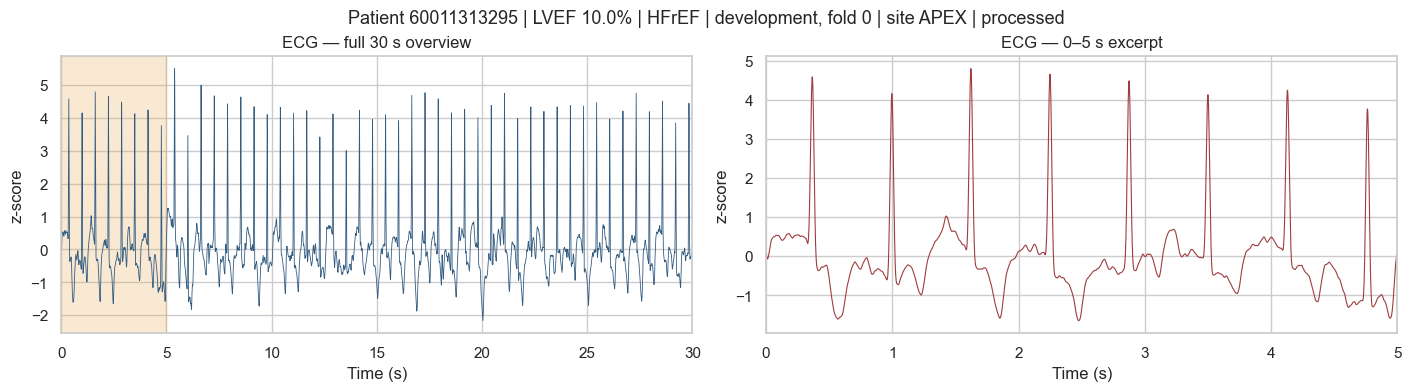

In [20]:
# Parameter-cell alternative: edit these values and rerun this cell.
VIEW_PATIENT_ID = scoped_index(DEFAULT_SCOPE).iloc[0].Patient_ID
VIEW_MODALITY = 'ECG'  # ECG, PCG, or paired
VIEW_SITE = DEFAULT_SITE
VIEW_REPRESENTATION = 'processed'  # processed, raw, or filtered
VIEW_START_S = DEFAULT_START_S
VIEW_DURATION_S = DEFAULT_DURATION_S
_ = plot_patient(VIEW_PATIENT_ID, VIEW_MODALITY, VIEW_SITE, VIEW_START_S,
                 VIEW_DURATION_S, VIEW_REPRESENTATION)

## Optional full-dataset integrity audit

A waveform can look plausible even when it came from the wrong patient, site, split, or label. This audit checks patient uniqueness, development/test separation, the LVEF label rule, channel order, file presence, tensor dimensions, and finite values. It does not remove or select patients.

Run it once after preprocessing or whenever the dataset changes. The exhaustive tensor scan is intentionally slower. After one successful audit, set `VALIDATE_ALL_SIGNAL_SHAPES = False` during routine visual browsing and turn it back on when the data changes.

In [21]:
errors = []
if patient_index['Patient_ID'].duplicated().any():
    errors.append('Patient IDs are not unique across development and test.')
if dev_ids & test_ids:
    errors.append(f'Development/test patient overlap: {sorted(dev_ids & test_ids)[:5]}')
if not patient_index['LVEF'].between(0, 1).all():
    errors.append('LVEF values must be fractions between 0 and 1.')
expected_labels = (patient_index['LVEF'] <= 0.40).astype(int)
if not patient_index['Label'].eq(expected_labels).all():
    errors.append('One or more labels disagree with LVEF <= 0.40.')
if not patient_index['Channel_Order'].eq(CHANNEL_ORDER_STRING).all():
    errors.append(f'Channel order must be {CHANNEL_ORDER_STRING}.')
if not patient_index.loc[patient_index.Split == 'development', 'Fold'].isin(range(5)).all():
    errors.append('Development folds must be 0 through 4.')
if not patient_index.loc[patient_index.Split == 'test', 'Fold'].eq(-1).all():
    errors.append('Test fold must be -1.')
for modality, (_, samples) in EXPECTED.items():
    declared = patient_index[f'{modality}_Samples']
    if not declared.eq(samples).all():
        errors.append(f'{modality} metadata does not consistently declare {samples} samples.')
    missing = [path for path in patient_index[f'{modality}_Path'] if not Path(path).is_file()]
    if missing:
        errors.append(f'Missing {modality} processed files: {missing[:3]}')
if errors:
    raise ValueError('Validation failed:\n- ' + '\n- '.join(errors))

shape_errors = []
if VALIDATE_ALL_SIGNAL_SHAPES:
    for row in patient_index.itertuples(index=False):
        for modality, (_, samples) in EXPECTED.items():
            path = Path(getattr(row, f'{modality}_Path'))
            tensor = torch.load(path, map_location='cpu', weights_only=True)
            if not isinstance(tensor, torch.Tensor) or tuple(tensor.shape) != (4, samples):
                shape_errors.append(f'{path}: got {getattr(tensor, "shape", type(tensor))}')
            elif not torch.isfinite(tensor).all():
                shape_errors.append(f'{path}: contains nonfinite values')
    if shape_errors:
        raise ValueError('Signal validation failed:\n- ' + '\n- '.join(shape_errors[:20]))

print(f'Validated {len(patient_index)} unique patients ({len(dev_ids)} development, {len(test_ids)} test).')
print('Processed ECG/PCG paths and declared dimensions are valid.')
print(f'Raw WAVs are complete for {patient_index.Raw_available.sum()}/{len(patient_index)} patients.')
if not VALIDATE_ALL_SIGNAL_SHAPES:
    print('Exhaustive tensor-content scan skipped; set VALIDATE_ALL_SIGNAL_SHAPES = True to run it.')

Validated 620 unique patients (500 development, 120 test).
Processed ECG/PCG paths and declared dimensions are valid.
Raw WAVs are complete for 620/620 patients.
Exhaustive tensor-content scan skipped; set VALIDATE_ALL_SIGNAL_SHAPES = True to run it.


## Dataset overview

`patient_index` contains the complete, numerically sorted table. The preview is intentionally bounded so the saved notebook stays readable.

,Split,Class,Patients,Proportion_within_split
0,development,HFrEF,60,12.0%
1,development,non-HFrEF,440,88.0%
2,test,HFrEF,5,4.2%
3,test,non-HFrEF,115,95.8%


,Split,Fold,Class,Patients,Proportion_within_fold
0,development,0,HFrEF,12,12.0%
1,development,0,non-HFrEF,88,88.0%
2,development,1,HFrEF,12,12.0%
3,development,1,non-HFrEF,88,88.0%
4,development,2,HFrEF,12,12.0%
5,development,2,non-HFrEF,88,88.0%
6,development,3,HFrEF,12,12.0%
7,development,3,non-HFrEF,88,88.0%
8,development,4,HFrEF,12,12.0%
9,development,4,non-HFrEF,88,88.0%


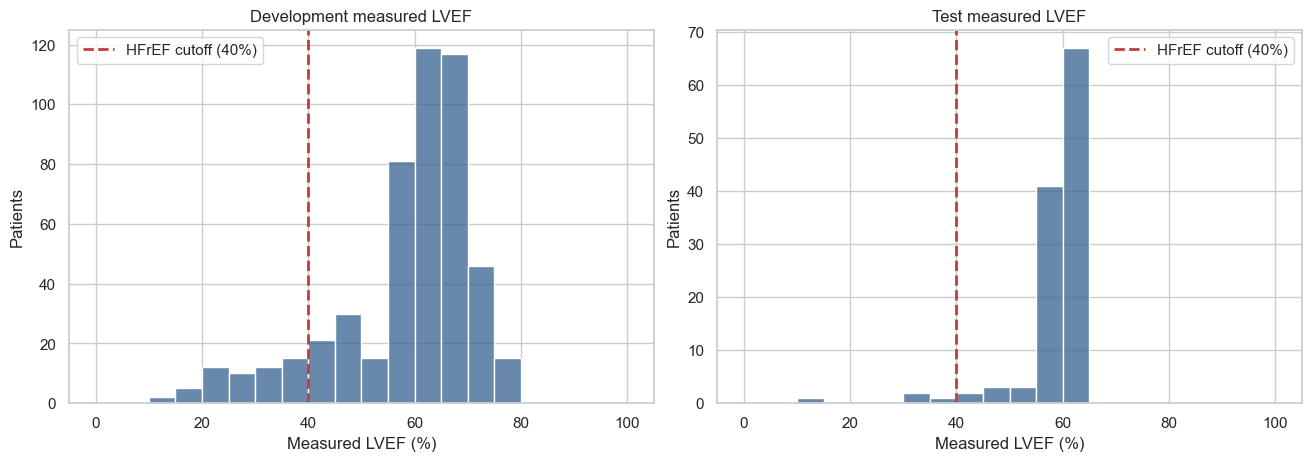

In [22]:
split_summary = (patient_index.groupby(['Split', 'Class'], observed=True)
                 .size().rename('Patients').reset_index())
split_summary['Proportion_within_split'] = (split_summary['Patients'] /
    split_summary.groupby('Split')['Patients'].transform('sum'))
fold_summary = (patient_index.groupby(['Split', 'Fold', 'Class'], observed=True)
                .size().rename('Patients').reset_index())
fold_summary['Proportion_within_fold'] = (fold_summary['Patients'] /
    fold_summary.groupby(['Split', 'Fold'])['Patients'].transform('sum'))
display(split_summary.style.format({'Proportion_within_split': '{:.1%}'}))
display(fold_summary.style.format({'Proportion_within_fold': '{:.1%}'}))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)
for ax, split in zip(axes, ('development', 'test')):
    values = patient_index.loc[patient_index.Split == split, 'LVEF_percent']
    sns.histplot(values, bins=np.arange(0, 101, 5), ax=ax, color='#35618f')
    ax.axvline(40, color='#c43b3b', linestyle='--', linewidth=2, label='HFrEF cutoff (40%)')
    ax.set(title=f'{split.title()} measured LVEF', xlabel='Measured LVEF (%)', ylabel='Patients')
    ax.legend()
plt.show()

# index_columns = ['Split', 'Fold', 'Patient_ID', 'LVEF_percent', 'Class',
#                  'ECG_Path', 'PCG_Path', 'Raw_available']
# with pd.option_context('display.max_rows', 25, 'display.max_colwidth', 45):
#     display(patient_index[index_columns].style.format({'LVEF_percent': '{:.1f}%'}))

## Transparent comparison groups

Selections are rebuilt within the requested split scope. Ties use patient ID. The random non-HFrEF sample uses `RANDOM_SEED`; no group uses model confidence or visual appearance.

In [23]:
GROUP_RULES = {
    'all_hfref': 'Every HFrEF patient, increasing measured LVEF',
    'lowest_lvef': f'Lowest {GROUP_N} measured LVEF values',
    'highest_lvef': f'Highest {GROUP_N} measured LVEF values',
    'random_non_hfref': f'Seeded random sample of {GROUP_N} non-HFrEF patients (seed={RANDOM_SEED})',
    'near_cutoff_hfref': f'Closest {GROUP_N} patients at or below the 40% cutoff',
    'near_cutoff_non_hfref': f'Closest {GROUP_N} patients above the 40% cutoff',
}

def build_comparison_groups(scope='development', n=GROUP_N, seed=RANDOM_SEED):
    data = scoped_index(scope).sort_values(['LVEF', 'Patient_ID'], kind='stable')
    hfref = data[data.Label == 1]
    non_hfref = data[data.Label == 0]
    groups = {
        'all_hfref': hfref,
        'lowest_lvef': data.head(n),
        'highest_lvef': data.sort_values(['LVEF', 'Patient_ID'], ascending=[False, True], kind='stable').head(n),
        'random_non_hfref': non_hfref.sample(n=min(n, len(non_hfref)), random_state=seed),
        'near_cutoff_hfref': hfref.assign(distance=0.40-hfref.LVEF).sort_values(['distance', 'Patient_ID']).head(n).drop(columns='distance'),
        'near_cutoff_non_hfref': non_hfref.assign(distance=non_hfref.LVEF-0.40).sort_values(['distance', 'Patient_ID']).head(n).drop(columns='distance'),
    }
    return {name: group.reset_index(drop=True) for name, group in groups.items()}

comparison_groups = build_comparison_groups(DEFAULT_SCOPE)
all_hfref_expected = scoped_index(DEFAULT_SCOPE).query('Label == 1')['Patient_ID'].tolist()
all_hfref_actual = comparison_groups['all_hfref']['Patient_ID'].tolist()
assert len(all_hfref_actual) == len(set(all_hfref_actual))
assert all_hfref_actual == all_hfref_expected
print(f'Complete HFrEF selection verified: {len(all_hfref_actual)} patients, each exactly once.')
for name, group in comparison_groups.items():
    print(f'\n{name}: {GROUP_RULES[name]} [{DEFAULT_SCOPE}; n={len(group)}]')
    display(group[['Patient_ID', 'Split', 'Fold', 'LVEF_percent', 'Class']].style.format({'LVEF_percent': '{:.1f}%'}))

Complete HFrEF selection verified: 60 patients, each exactly once.

all_hfref: Every HFrEF patient, increasing measured LVEF [development; n=60]


,Patient_ID,Split,Fold,LVEF_percent,Class
0,60011313295,development,0,10.0%,HFrEF
1,60012224696,development,1,10.0%,HFrEF
2,60012257804,development,1,15.0%,HFrEF
3,1011468875,development,2,17.0%,HFrEF
4,60012909152,development,4,17.0%,HFrEF
5,60012944614,development,0,17.0%,HFrEF
6,60012358520,development,0,18.0%,HFrEF
7,1011412735,development,2,21.0%,HFrEF
8,60012787426,development,3,21.0%,HFrEF
9,2502271878,development,1,22.0%,HFrEF



lowest_lvef: Lowest 10 measured LVEF values [development; n=10]


,Patient_ID,Split,Fold,LVEF_percent,Class
0,60011313295,development,0,10.0%,HFrEF
1,60012224696,development,1,10.0%,HFrEF
2,60012257804,development,1,15.0%,HFrEF
3,1011468875,development,2,17.0%,HFrEF
4,60012909152,development,4,17.0%,HFrEF
5,60012944614,development,0,17.0%,HFrEF
6,60012358520,development,0,18.0%,HFrEF
7,1011412735,development,2,21.0%,HFrEF
8,60012787426,development,3,21.0%,HFrEF
9,2502271878,development,1,22.0%,HFrEF



highest_lvef: Highest 10 measured LVEF values [development; n=10]


...

,Patient_ID,Split,Fold,LVEF_percent,Class
0,1010442088,development,2,65.0%,non-HFrEF
1,60011099172,development,0,56.0%,non-HFrEF
2,60012899591,development,1,68.0%,non-HFrEF
3,60012858819,development,2,64.0%,non-HFrEF
4,60012410175,development,2,67.0%,non-HFrEF
5,2002660214,development,3,66.0%,non-HFrEF
6,60012696694,development,2,61.0%,non-HFrEF
7,60012263919,development,3,56.0%,non-HFrEF
8,60012474767,development,2,79.0%,non-HFrEF
9,60010635511,development,2,72.0%,non-HFrEF



near_cutoff_hfref: Closest 10 patients at or below the 40% cutoff [development; n=10]


,Patient_ID,Split,Fold,LVEF_percent,Class
0,2502420464,development,3,40.0%,HFrEF
1,60012172071,development,4,40.0%,HFrEF
2,60012192050,development,4,40.0%,HFrEF
3,60012195182,development,3,40.0%,HFrEF
4,1008922101,development,4,39.0%,HFrEF
5,1010358116,development,4,39.0%,HFrEF
6,60012182370,development,0,39.0%,HFrEF
7,60012231951,development,0,39.0%,HFrEF
8,60012251349,development,4,38.0%,HFrEF
9,60012870763,development,3,38.0%,HFrEF



near_cutoff_non_hfref: Closest 10 patients above the 40% cutoff [development; n=10]


,Patient_ID,Split,Fold,LVEF_percent,Class
0,60012153756,development,2,41.0%,non-HFrEF
1,1010243090,development,2,42.0%,non-HFrEF
2,60011997893,development,3,42.0%,non-HFrEF
3,60012205517,development,4,42.0%,non-HFrEF
4,60012233080,development,1,42.0%,non-HFrEF
5,60013315822,development,4,42.0%,non-HFrEF
6,1010119114,development,3,43.0%,non-HFrEF
7,1010830820,development,1,43.0%,non-HFrEF
8,2502279792,development,3,43.0%,non-HFrEF
9,60012221906,development,0,43.0%,non-HFrEF


## Paginated galleries and patient-to-patient comparison

Gallery pages use the same site, time window, representation, and y-axis range within each page. Rebuild groups with `build_comparison_groups('test')` or `build_comparison_groups('all')` to inspect those scopes explicitly.

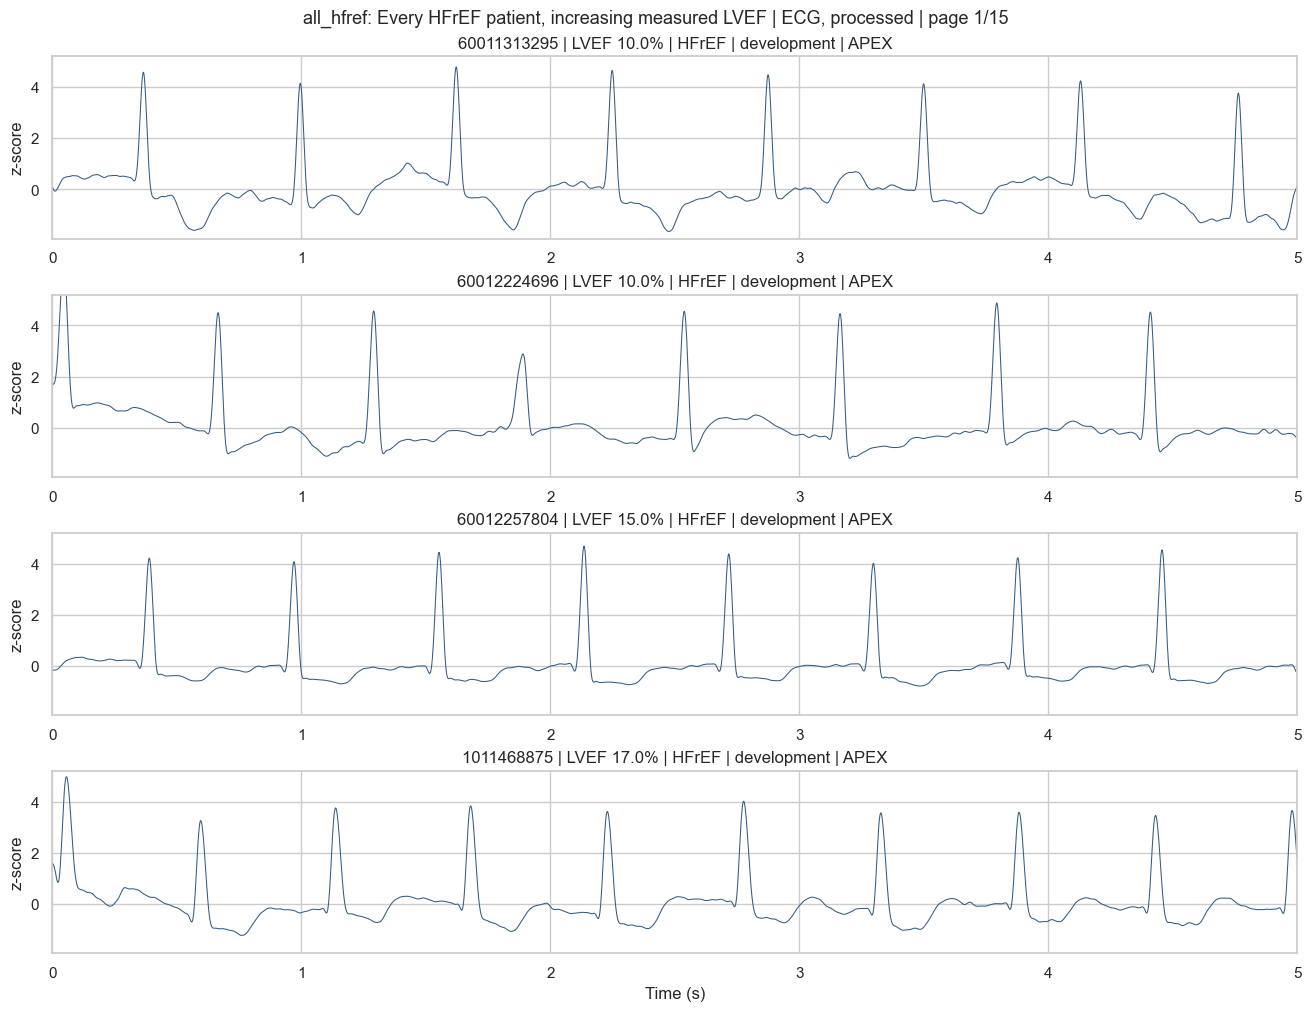

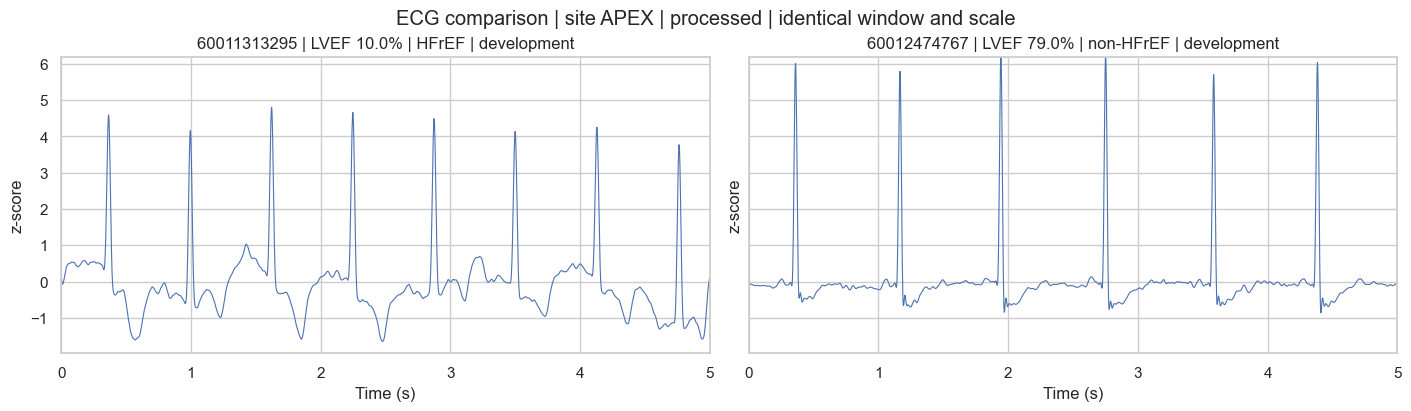

In [24]:
def gallery(group_name='all_hfref', page=1, scope=DEFAULT_SCOPE, modality='ECG',
            site=DEFAULT_SITE, start_s=DEFAULT_START_S, duration_s=DEFAULT_DURATION_S,
            representation='processed', page_size=GALLERY_PAGE_SIZE):
    groups = build_comparison_groups(scope)
    if group_name not in groups:
        raise KeyError(f'Choose one of {list(groups)}')
    group = groups[group_name]
    pages = max(1, int(np.ceil(len(group) / page_size)))
    if page < 1 or page > pages:
        raise ValueError(f'page must be from 1 to {pages}')
    selected = group.iloc[(page - 1) * page_size:page * page_size]
    traces = []
    for row in selected.itertuples(index=False):
        values, fs, unit = load_signal(row.Patient_ID, modality, site, representation, row.Split)
        left, right = int(start_s * fs), int((start_s + duration_s) * fs)
        traces.append((row, np.arange(left, right) / fs, values[left:right], unit))
    if not traces:
        print(f'No patients in {group_name} for {scope}.')
        return None
    y_min = min(np.nanpercentile(trace[2], 0.5) for trace in traces)
    y_max = max(np.nanpercentile(trace[2], 99.5) for trace in traces)
    margin = max((y_max - y_min) * 0.05, 1e-6)
    fig, axes = plt.subplots(len(traces), 1, figsize=(13, 2.5 * len(traces)), squeeze=False, constrained_layout=True)
    for ax, (row, times, values, unit) in zip(axes[:, 0], traces):
        ax.plot(times, values, linewidth=0.75, color='#335c81')
        ax.set(xlim=(start_s, start_s + duration_s), ylim=(y_min - margin, y_max + margin),
               ylabel=unit, title=f'{row.Patient_ID} | LVEF {row.LVEF_percent:.1f}% | {row.Class} | {row.Split} | {site}')
    axes[-1, 0].set_xlabel('Time (s)')
    fig.suptitle(f'{group_name}: {GROUP_RULES[group_name]} | {modality}, {representation} | page {page}/{pages}', fontsize=13)
    plt.show()
    return fig

def compare_patients(patient_a, patient_b, modality='ECG', site=DEFAULT_SITE,
                     start_s=DEFAULT_START_S, duration_s=DEFAULT_DURATION_S, representation='processed'):
    rows = [patient_row(patient_a), patient_row(patient_b)]
    loaded = []
    for row in rows:
        values, fs, unit = load_signal(row.Patient_ID, modality, site, representation, row.Split)
        left, right = int(start_s * fs), int((start_s + duration_s) * fs)
        loaded.append((row, np.arange(left, right) / fs, values[left:right], unit))
    y_min = min(np.nanpercentile(item[2], 0.5) for item in loaded)
    y_max = max(np.nanpercentile(item[2], 99.5) for item in loaded)
    margin = max((y_max - y_min) * 0.05, 1e-6)
    fig, axes = plt.subplots(1, 2, figsize=(14, 4), constrained_layout=True, sharey=True)
    for ax, (row, times, values, unit) in zip(axes, loaded):
        ax.plot(times, values, linewidth=0.8)
        ax.set(xlabel='Time (s)', ylabel=unit, xlim=(start_s, start_s + duration_s), ylim=(y_min-margin, y_max+margin),
               title=f'{row.Patient_ID} | LVEF {row.LVEF_percent:.1f}% | {row.Class} | {row.Split}')
    fig.suptitle(f'{modality} comparison | site {site} | {representation} | identical window and scale')
    plt.show()
    return fig

_ = gallery('all_hfref', page=1, scope=DEFAULT_SCOPE)
_ = compare_patients(comparison_groups['lowest_lvef'].iloc[0].Patient_ID,
                     comparison_groups['highest_lvef'].iloc[0].Patient_ID)

## Raw, filtered, and processed representations

Use this comparison to separate recording-scale effects from standardized morphology. Filtering is for display only and does not modify saved data. Raw and filtered panels share their scale; processed values use a separate z-score scale.

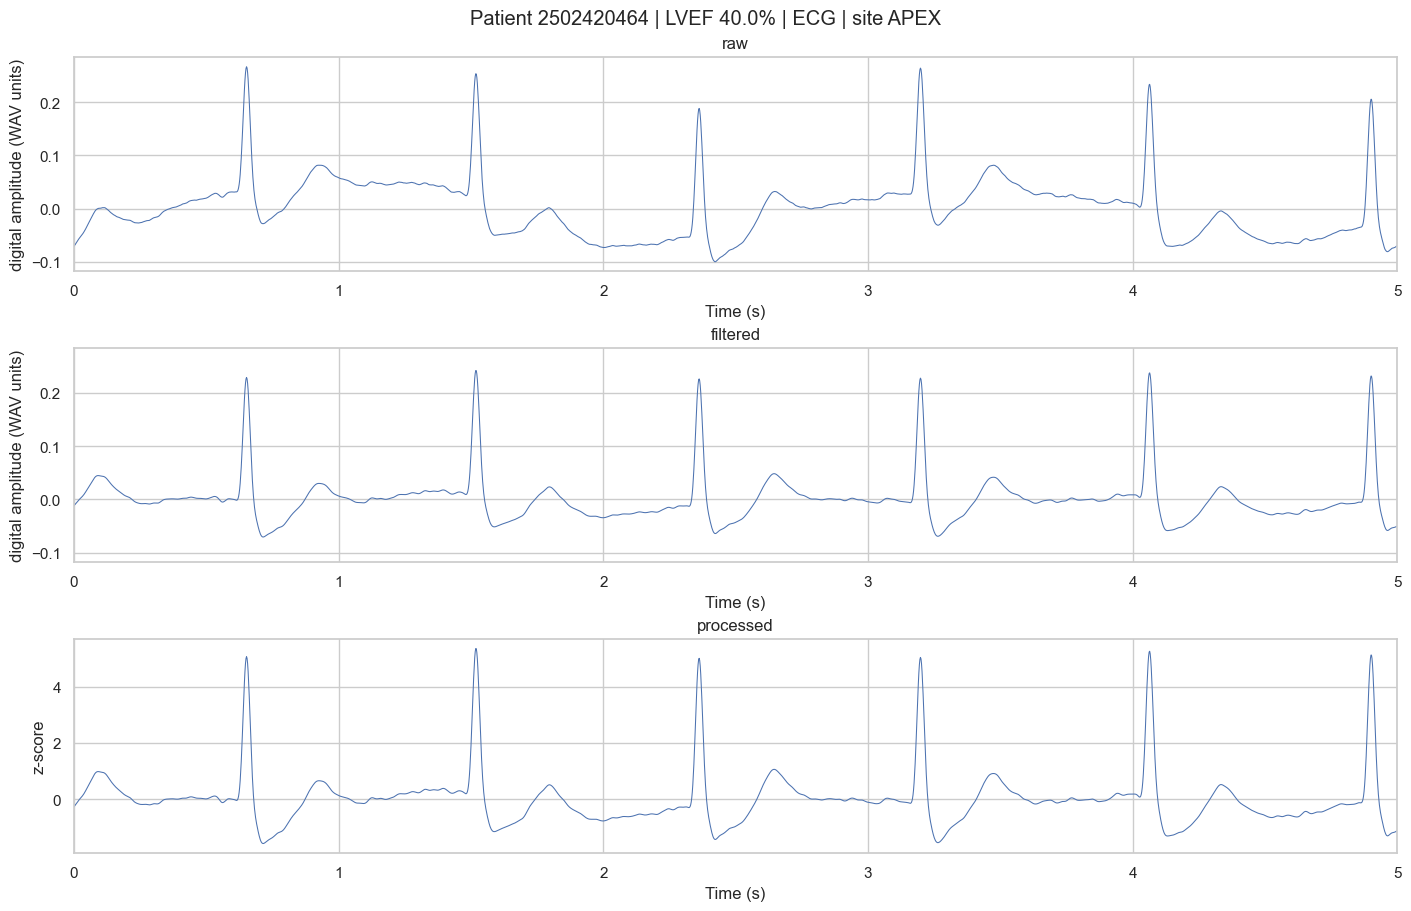

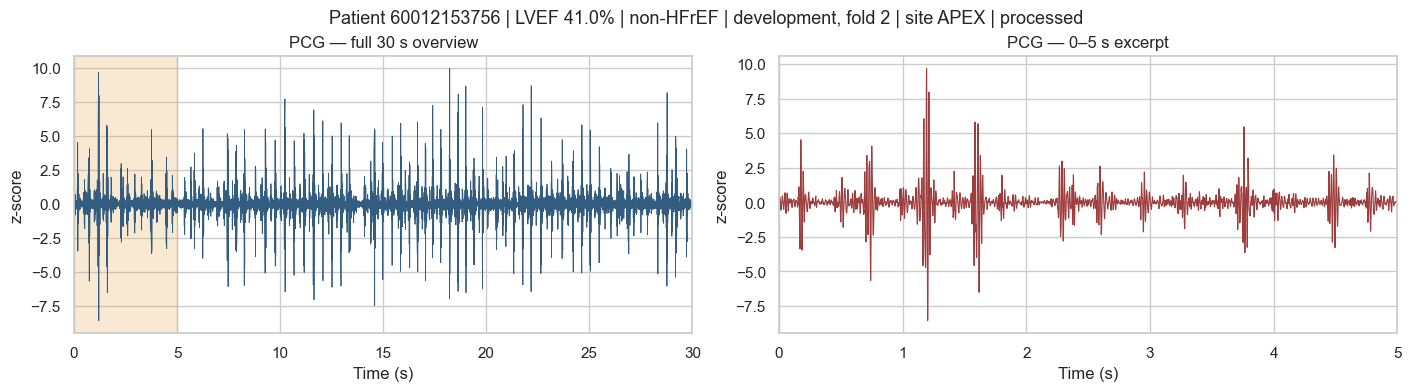

In [25]:
def compare_representations(patient_id, modality='ECG', site=DEFAULT_SITE,
                            start_s=DEFAULT_START_S, duration_s=DEFAULT_DURATION_S):
    row = patient_row(patient_id)
    available = ['processed'] if not row.Raw_available else ['raw', 'filtered', 'processed']
    fig, axes = plt.subplots(len(available), 1, figsize=(14, 3 * len(available)), squeeze=False, constrained_layout=True)
    raw_limits = None
    for ax, representation in zip(axes[:, 0], available):
        values, fs, unit = load_signal(row.Patient_ID, modality, site, representation, row.Split)
        left, right = int(start_s * fs), int((start_s + duration_s) * fs)
        excerpt = values[left:right]
        times = np.arange(left, right) / fs
        ax.plot(times, excerpt, linewidth=0.75)
        ax.set(xlabel='Time (s)', ylabel=unit, xlim=(start_s, start_s + duration_s), title=representation)
        if representation == 'raw':
            raw_limits = ax.get_ylim()
        elif representation == 'filtered' and raw_limits is not None:
            ax.set_ylim(raw_limits)
    fig.suptitle(f'Patient {row.Patient_ID} | LVEF {row.LVEF_percent:.1f}% | {modality} | site {site}')
    plt.show()
    return fig

RAW_COMPARISON_PATIENT = comparison_groups['near_cutoff_hfref'].iloc[0].Patient_ID
_ = compare_representations(RAW_COMPARISON_PATIENT, modality='ECG')

# Representative PCG boundary case, using the same default window.
PCG_BOUNDARY_PATIENT = comparison_groups['near_cutoff_non_hfref'].iloc[0].Patient_ID
_ = plot_patient(PCG_BOUNDARY_PATIENT, modality='PCG', site=DEFAULT_SITE,
                 start_s=DEFAULT_START_S, duration_s=DEFAULT_DURATION_S)

## Visual-review checklist and notes

Use repeated observations across patients and sites to form testable hypotheses. Avoid interpreting a trace as a diagnosis or as proof of what the model learned.

- Rhythm regularity and repeating intervals within one recording
- Recurring morphology differences visible across several patients
- Baseline drift, high-frequency noise, clipping, or dropouts
- Differences between acquisition sites, without assuming simultaneous timing
- Whether a suspected pattern remains visible near the 40% boundary and in randomly selected controls
- Whether an apparent group difference could instead reflect recording quality or preprocessing

The empty table below is a structured place for observations. Add rows manually.

In [ ]:
observation_notes = pd.DataFrame([{'Patient_ID': '1008663920'}], columns=[
    'Patient_ID', 'Site', 'Time_interval_s', 'Observation',
    'Possible_artifact', 'Hypothesis_to_investigate',
]).fillna('')

display(observation_notes)

,Patient_ID,Site,Time_interval_s,Observation,Possible_artifact,Hypothesis_to_investigate
0,1008663920,,,,,
